

# Multiple Linear Regression


## Demo


- importing the libraries and opening the file
- reading the csv file
- making plot 
- fit and train the model

### Importing Needed packages


In [140]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


<h2 id="reading_data">Reading the data</h2>


In [141]:
df = pd.read_csv("Regression/FuelConsumption.csv")

# take a look at the dataset
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


#### Select the things we want to work with

In [142]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_CITY','FUELCONSUMPTION_HWY','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.head(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,9.9,6.7,8.5,196
1,2.4,4,11.2,7.7,9.6,221
2,1.5,4,6.0,5.8,5.9,136
3,3.5,6,12.7,9.1,11.1,255
4,3.5,6,12.1,8.7,10.6,244
5,3.5,6,11.9,7.7,10.0,230
6,3.5,6,11.8,8.1,10.1,232
7,3.7,6,12.8,9.0,11.1,255
8,3.7,6,13.4,9.5,11.6,267


### The plot :

### Creating train and test dataset

In the **Train/Test split** process, a dataset is split into two parts: 80% for training the model and 20% for testing the model. In this manner, the model is tested on data that it has never seen before; therefore, this is a better way to measure how well the model will generalize to new data. The splitting process is typically done by random split (using `np.random.rand()`).


In [165]:
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]


#### Train data distribution


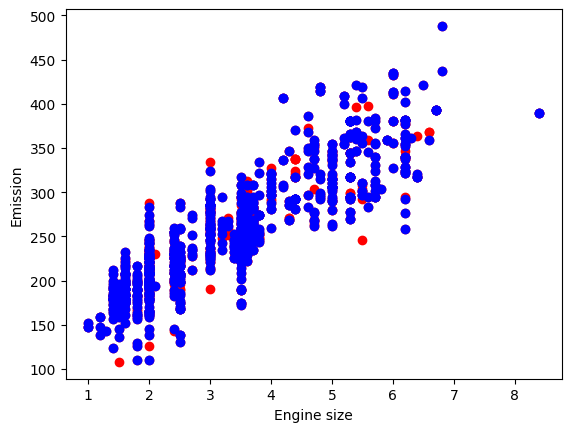

In [166]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS,  color='red')
ax.scatter(train.ENGINESIZE, train.CO2EMISSIONS,  color='blue')


plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()


<h2 id="multiple_regression_model">Multiple Regression Model</h2>


In reality, there are multiple variables that impact the Co2emission. When more than one independent variable is present, the process is called multiple linear regression. An example of multiple linear regression is predicting co2emission using the features FUELCONSUMPTION_COMB, EngineSize and Cylinders of cars. The good thing here is that multiple linear regression model is the extension of the simple linear regression model.


In [167]:
from sklearn import linear_model

regr = linear_model.LinearRegression()

regr.fit(train[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']], train['CO2EMISSIONS'])

print('Coefficients: ', regr.coef_)
print('Intercept: ', regr.intercept_)


Coefficients:  [10.15885005  8.10449406  9.746543  ]
Intercept:  62.4553498215551


As mentioned before, **Coefficient** and **Intercept**  are the parameters of the fitted line.
Given that it is a multiple linear regression model with 3 parameters and that the parameters are the intercept and coefficients of the hyperplane, sklearn can estimate them from our data. Scikit-learn uses plain Ordinary Least Squares method to solve this problem.

#### Ordinary Least Squares (OLS)

OLS is a method for estimating the unknown parameters in a linear regression model. OLS chooses the parameters of a linear function of a set of explanatory variables by minimizing the sum of the squares of the differences between the target dependent variable and those predicted by the linear function. In other words, it tries to minimizes the sum of squared errors (SSE) or mean squared error (MSE) between the target variable (y) and our predicted output ($\hat{y}$) over all samples in the dataset.

OLS can find the best parameters using of the following methods:

*   Solving the model parameters analytically using closed-form equations
*   Using an optimization algorithm (Gradient Descent, Stochastic Gradient Descent, Newton’s Method, etc.)


<h2 id="prediction">Prediction</h2>


In [168]:
y_hat= regr.predict(test[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']])
x = np.asanyarray(test[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']])
y = np.asanyarray(test[['CO2EMISSIONS']])


print("Residual sum of squares: %.2f" % np.mean((y_hat - y) ** 2))
print('Variance score: %.2f' % regr.score(test[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']], y))

Residual sum of squares: 6260.87
Variance score: 0.83


**Explained Variance Regression Score:**

$$
\text{Explained Variance} = 1 - \frac{\text{Var}(y - \hat{y})}{\text{Var}(y)}
$$

The best possible score is **1.0**, indicating a perfect prediction, while lower values suggest worse performance.


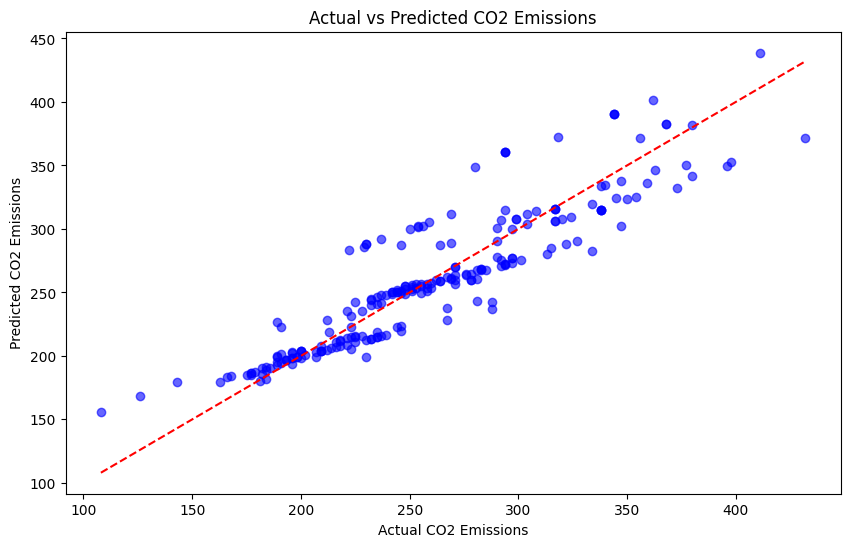

In [169]:
import matplotlib.pyplot as plt
 
plt.figure(figsize=(10, 6))

plt.scatter(y, y_hat, color='blue', label='Predicted vs Actual', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual CO2 Emissions')
plt.ylabel('Predicted CO2 Emissions')
plt.title('Actual vs Predicted CO2 Emissions')
plt.show()


